# Aufgabenstellung
1. Nehmen Sie die Isothermen von $SF_6$ für acht Temperaturen auf. Eine Temperatur sollte oberhalb der kritischen Temperatur gewählt werden. Die Temperatur darf $55$°C nicht überschreiten, da sonst die Gefahr besteht, die Kapillare zu zerstören.

2. Zeichnen Sie die Isothermen und ermitteln Sie den Wert für den Sättigungsdruck ps im Bereich der Maxwell-Geraden (Koexistenz von Flüssigkeit und Dampf).

3. Stellen Sie $ln(p_s)$ als Funktion von ($1/T$) graphisch dar. Passen Sie die Dampfdruckgleichung an die Daten an und bestimmen Sie die mittlere molare Verdampfungswärme der untersuchten Substanz.

4. Ermitteln Sie die Stoffmenge der untersuchten Substanz.

5. Bestimmen Sie die Verdampfungswärme als Funktion der Temperatur mittels der Clausius-Clapeyron-Gleichung. Stellen Sie die Verdampfungswärme als Funktion von $T/T_K$ graphisch dar und
passen Sie ein Potenzgesetz an die Daten an.

# Aufgabe 2
Für die zweite Aufgabe suchen wir für jede Messung den Sättigungsdruck. Beim Sättigungsdruck handelt es sich um den Druck, bei dem es eine Koexistenz von Flüssigkeit und Dampf und es ein Plateau im pV-Diagramm gibt. Diese Plateau heißt, dass es einen konstanten Druck bei Volumenänderung gibt und tritt beim Phasenübergang von flüssig und gasförmig auf. Dieses Plateau kommt nur bei Temperaturen unterhalb der kritschen Temperatur $T_{k}$ vor, deshalb haben nicht alle von unseren Messdaten einen Wert von $p_s$.

Wir bestimmen den Wert, indem wir erstmal die einzelnen Isotherme plotten und innerhalb dieser Datensätze gucken, ob es zwischen benachbarten Druckwerten einen sehr geringen Unterschied gibt. Dieser wird dann als Sättigungsdruck ausgegeben.

Aufälligkeiten sind dabei dass die Isothermen bei höheren Temperaturen immer weniger ausgeprägt sind und die Plateau-Phase immer kürzer wird, bis sie wie in der letzten Isotherme gar nicht mehr zu erkenn ist oder wie in der vorletzten Isothermen, so schwach das sie sich nicht richtig auswerten lässt. Deshalb musste die Isotherme bei 46.5°C auch händisch ausgewertet werden. Dies liegt daran, dass es an dem Punkt die Unterschiede zwischen der flüssigen und der gasförmigen Phase verschwinden und somit keine Phasenübergang stattfindet. Was auch noch auffällt ist, das manche Messpunkt, bei dem Plateau etwas tiefer liegen als ihr linker Nachbarpunkt, was auf eine Mesungenauigkeit hindeutet. Während des Messens hatten wir folgende Messunsicherheiten, da die Skalen auf den Messgeräten nicht kleiner waren.
Abweichung bei Volumina $\pm0.25\text{ml}$
Abweichung bei Druck $\pm25\text{kPa}$
 

Sättigungsdruck bei 31.5 °C: 27.42 10^5 Pa
Sättigungsdruck bei 34.4 °C: 29.25 10^5 Pa
Sättigungsdruck bei 37.5 °C: 31.50 10^5 Pa
Sättigungsdruck bei 40.5 °C: 34.00 10^5 Pa
Sättigungsdruck bei 43.5 °C: 36.25 10^5 Pa
Sättigungsdruck bei 46.5 °C: 38.75 10^5 Pa


<Figure size 900x2000 with 0 Axes>

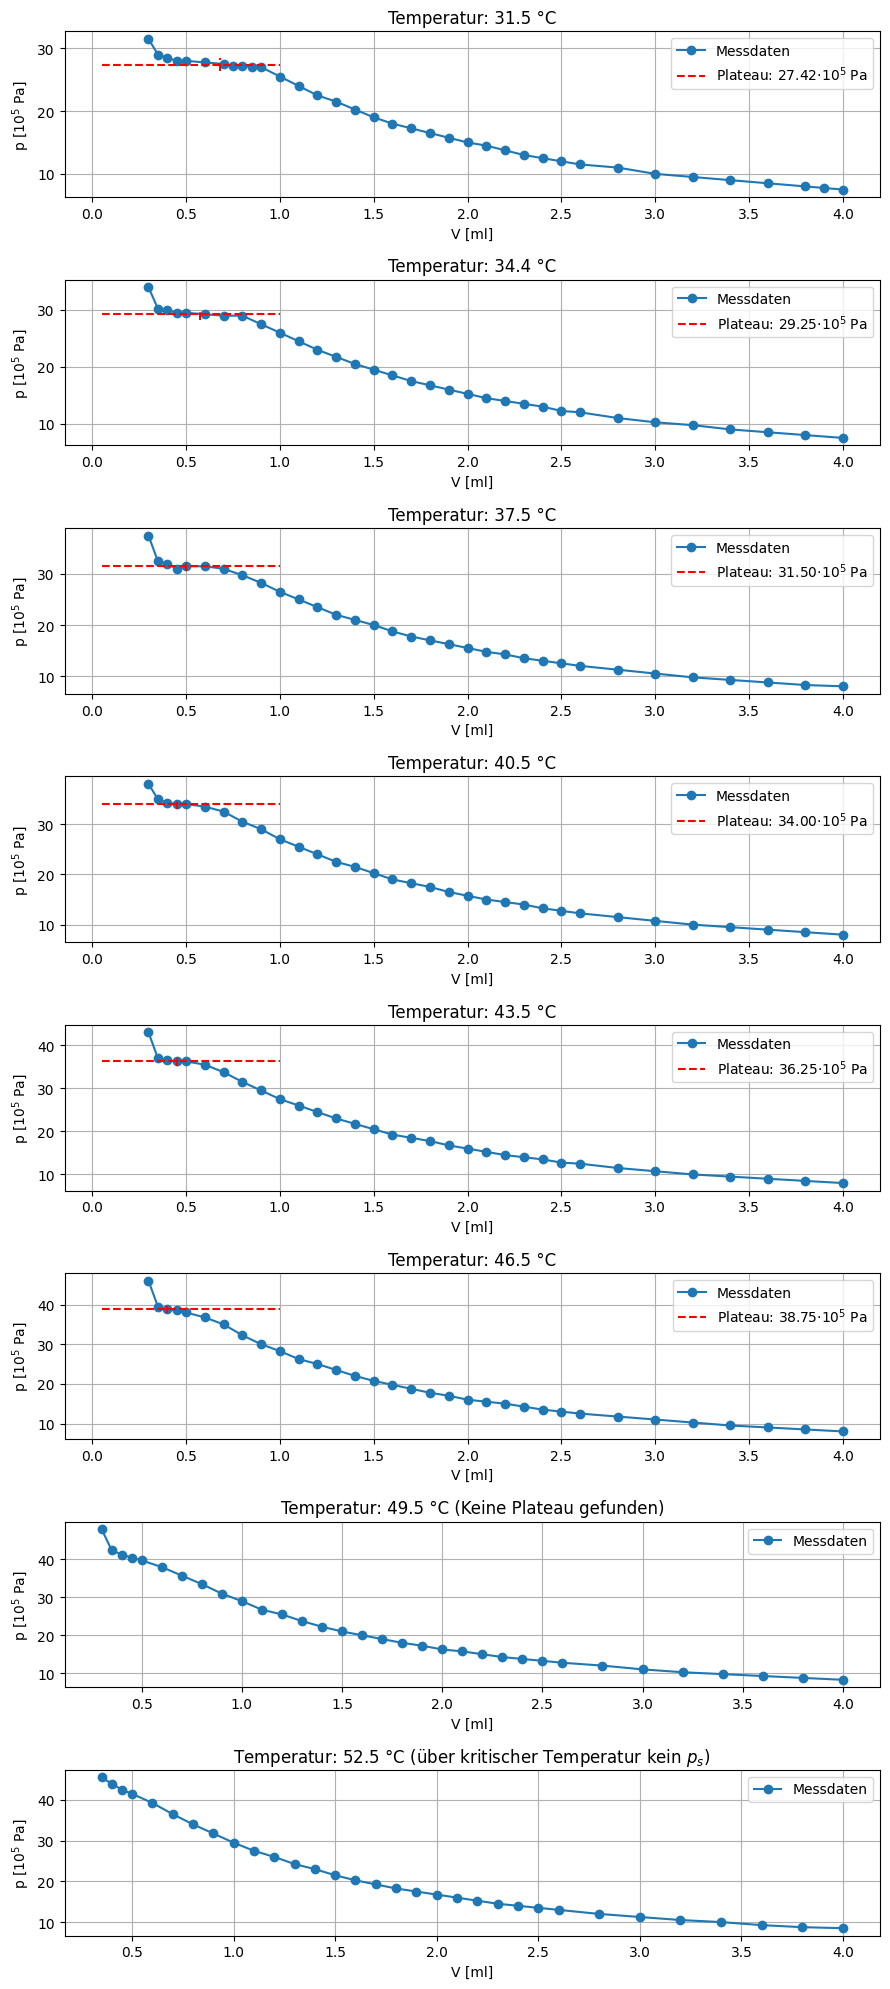

In [14]:
# | label: fig-sättigungsdruck
# | fig-cap: Die Abbildung zeigt acht verschiedene Plots mit den Isothermen zu verscheidenen Temperaturen, dabei wurde der Sättigungsdruck $p_s$ mittels einer Plateau-Mittelung gemacht wurde. Dabei wurden die ersten 5 Plots maschinell herausgefunden, der 6te wurde händisch ermittelt und die zwei anderen konnten nicht ermittelt werden, da kein eindeutiges Plot ersichtlich war.
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from natsort import natsorted
import os

#TODO: Abweichung eintragen Plot Hübsch machen

volumen = []
druck = []
temperatur = []

# Ordnerpfad anpassen
filepath = "Daten"

# Alle CSV-Dateien holen und sortieren
csv_files = [f for f in os.listdir(filepath) if f.endswith('.csv')]
csv_files = natsorted(csv_files)

plateau_val = np.array([])
plateau_vol = np.array([])
temp = np.array([]) 


for filename in csv_files:
    # CSV einlesen
    df = pd.read_csv(os.path.join(filepath, filename))
    df.columns = ['V[ml]', 'p [10^5 Pa]']

    # Temperatur aus dem Dateinamen extrahieren
    _temp = filename[9:13]
    _temp = _temp.replace('_', '.')
    _temp = float(_temp)

    # Daten in Listen speichern
    volumen.append(df['V[ml]'])
    druck.append(df['p [10^5 Pa]'])
    temperatur.append(_temp)

    # Sättigungsdruck berechnen
    # Differenz zwischen benachbarten Druckwerten berechnen
    dp = df['p [10^5 Pa]'].diff().abs()
    plateau_indices = dp[dp < 0.01].index  # Toleranz anpassen
    sättigungsdruck = df.loc[plateau_indices, 'p [10^5 Pa]'].mean()
    if np.isnan(sättigungsdruck):
        continue
    plateau_val= np.append(plateau_val, sättigungsdruck)
    plateau_vol = np.append(plateau_vol, df.loc[plateau_indices, 'V[ml]'].mean())
    temp = np.append(temp, _temp)
    print(f"Sättigungsdruck bei {_temp} °C: {sättigungsdruck:.2f} 10^5 Pa")

# Händisch ausgelesene Daten (wenn dp < 0.26 findet er was für den 6ten Plot aber dann ist für die anderen Schlecht)
plateau_val= np.append(plateau_val, 38.75)
plateau_vol = np.append(plateau_vol, 0.4)
temp = np.append(temp, 46.5)
print(f"Sättigungsdruck bei 46.5 °C: 38.75 10^5 Pa")

# Plotten der Messdaten
plt.figure(figsize=(9, 20))
fig, axs = plt.subplots(8, 1, figsize=(9, 20))  # Re-declare figsize here too
axs = axs.flatten()

for i in range(len(axs)):
    axs[i].plot(volumen[i], druck[i], label='Messdaten', marker='o')
    
    if i < 6:
        axs[i].set_title(f"Temperatur: {temperatur[i]} °C", )
        axs[i].hlines(plateau_val[i], 0.05, 1, colors='r', linestyles='--', label=f'Plateau: {plateau_val[i]:.2f}$\cdot 10^5$ Pa')
        axs[i].vlines(plateau_vol[i], plateau_val[i] - 1, plateau_val[i] + 1, colors='r', linestyles='--')
    elif i == 6:
        axs[i].set_title(f"Temperatur: {temperatur[i]} °C (Keine Plateau gefunden)", )
    else:
        axs[i].set_title(f"Temperatur: {temperatur[i]} °C (über kritischer Temperatur kein $p_s$)", )
    axs[i].set_xlabel("V [ml]", )
    axs[i].set_ylabel("p [$10^5$ Pa]",)
    axs[i].tick_params(axis='both', which='major', )
    axs[i].grid(True)
    axs[i].legend()

plt.tight_layout()
plt.show()

# Aufgabe 3
In Aufgabe 3 soll $ln(p_s)$ als Funktion von ($1/T$) graphisch dargestellt werden. Dafür soll die Dampfdruckgleichung an die Daten angepasst werden, um die mittlere molare Verdampfungswärme der untersuchten Substanz zu bestimmen. Dafür wurden zuerst alle Temperaturen in Kelvin umgerechnet. Für den Fit haben wir die Clausius-Clapeyron-Gleichung verwendet, die wie folgt lautet:
$$\frac{d p_s}{dT} = \frac{Q_{23}}{T \Delta V_m}$$
Diese kann für Temperaturen weit unterhalb der kritischen Temperatur, wie in den ersten 6 Plots in [Abbildung @fig-sättigungsdruck] zu sehen ist, zu einer vereinfachten Differentialgleichung umgeschrieben werden:
$$\frac{d p_s}{dT} = \frac{p_s Q_{23}}{R T^2}$$
Mittels Trennung der Variablen zu folgender GLeichung, kann die Differentialgleichung mittels Integration gelöst werden.
$$\int \frac{1}{p_s} dp_s = -\frac{Q_{23}}{R} \int \frac{1}{T} dT$$
So kann die Clausius-Clapeyron-Gleichung umgeschrieben werden zu:
$$ln(p_s) = -\frac{Q_{23}}{R}\frac{1}{T} + C$$
Was einer linearen Abnhängigkeit ($y = mx +b$) von $ln(p_s)$ und $1/T$ entspricht. Man sieht außerdem, dass die Steigung der Geraden $-\frac{Q_{23}}{R}$ ist. Daraus folgt, dass die mittlere molare Verdampfungswärme $Q_{23}$ mit der Formel
$Q_{23} = -m R$ berechnet werden kann. Weshalb für den Fit eine lineare Regression benutzt wurde, da dies sich als unkomplizierteste Methode herrausgestellt hat.
In [Abbildung @fig-sieben] konnte so ein Wert von $Q_{23} = 66.23$ kJ/mol ermittelt werden, für die mittlere molare Verdämpfungswärme.

Q_23 = 66.23 kJ/mol


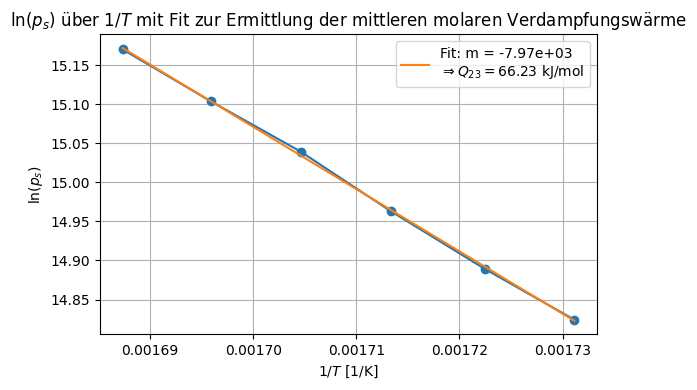

In [ ]:
# | fig-cap: $\ln(p_s)$ über $1/T$ mit Fit (linearer Regression) zur Ermittlung der mittleren molaren Verdampfungswärme Q_{23}
# | label: fig-sieben
from scipy.stats import linregress

p_s = plateau_val * 10 ** 5
# temp is a tuple, use the first element which is the array of temperatures in Celsius
temp_kelvin = np.array(temp[0]) + 273.15  # Convert to Kelvin
invT = 1/temp_kelvin

# Lineare Regression
slope, intercept, r_value, p_value, std_err = linregress(invT, np.log(p_s))

R = 8.314  # J/mol·K
Q = -slope * R  # J/mol
#print(f"Q_23 = {Q/1000:.2f} kJ/mol")

plt.figure(figsize=(6,4))
plt.plot(1 / temp_kelvin, np.log(p_s), marker='o')
x_fit = np.linspace(invT.min(), invT.max(), 100)
plt.plot(x_fit, slope*x_fit + intercept, '-', label=f'Fit: m = {slope:.2e}\n' + '$ \\Rightarrow Q_{23} = ' + f'{Q/1000:.2f}' + '$ kJ/mol')
plt.xlabel("$1/T$ [1/K]")
plt.ylabel("$\ln(p_s)$")
plt.title("$\ln(p_s)$ über $1/T$ mit Fit zur Ermittlung der mittleren molaren Verdampfungswärme")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Aufgabe 4

## Bestimmung der Stoffmenge n

Um die Stoffmenge zu berechnen nutzen wir die ideale Gasgleichung $pV = nRT$. Wir haben zwar kein ideales Gas, aber ein sehr stark verdünntes Gas als Näherung eines idealen Gases beschrieben werden kann. Also ein hohes Volumen bzw. ein sehr kleines $1/V$:
$$\textrm{lim}_{V\rightarrow \infty}(pV) = nRT$$

Als erstes Stellen wir $pV$ gegen $1/V$ für jede Temperatur in einem Plot da und finden einen Fit dafür. Wenn wir uns den y-Achsenabschnitt dieses Fits anschauen, finden wir den Wert für $\textrm{lim}_{V\rightarrow \infty}(pV)$. Wenn wir diesen Wert noch durch $RT$ teilen, kriegen wir für jede Temperatur die Stoffmenge heraus. Den Mittelwert der 8 Werte nutzen wir dann als bestimmte Stoffmenge n.

<Figure size 900x2000 with 0 Axes>

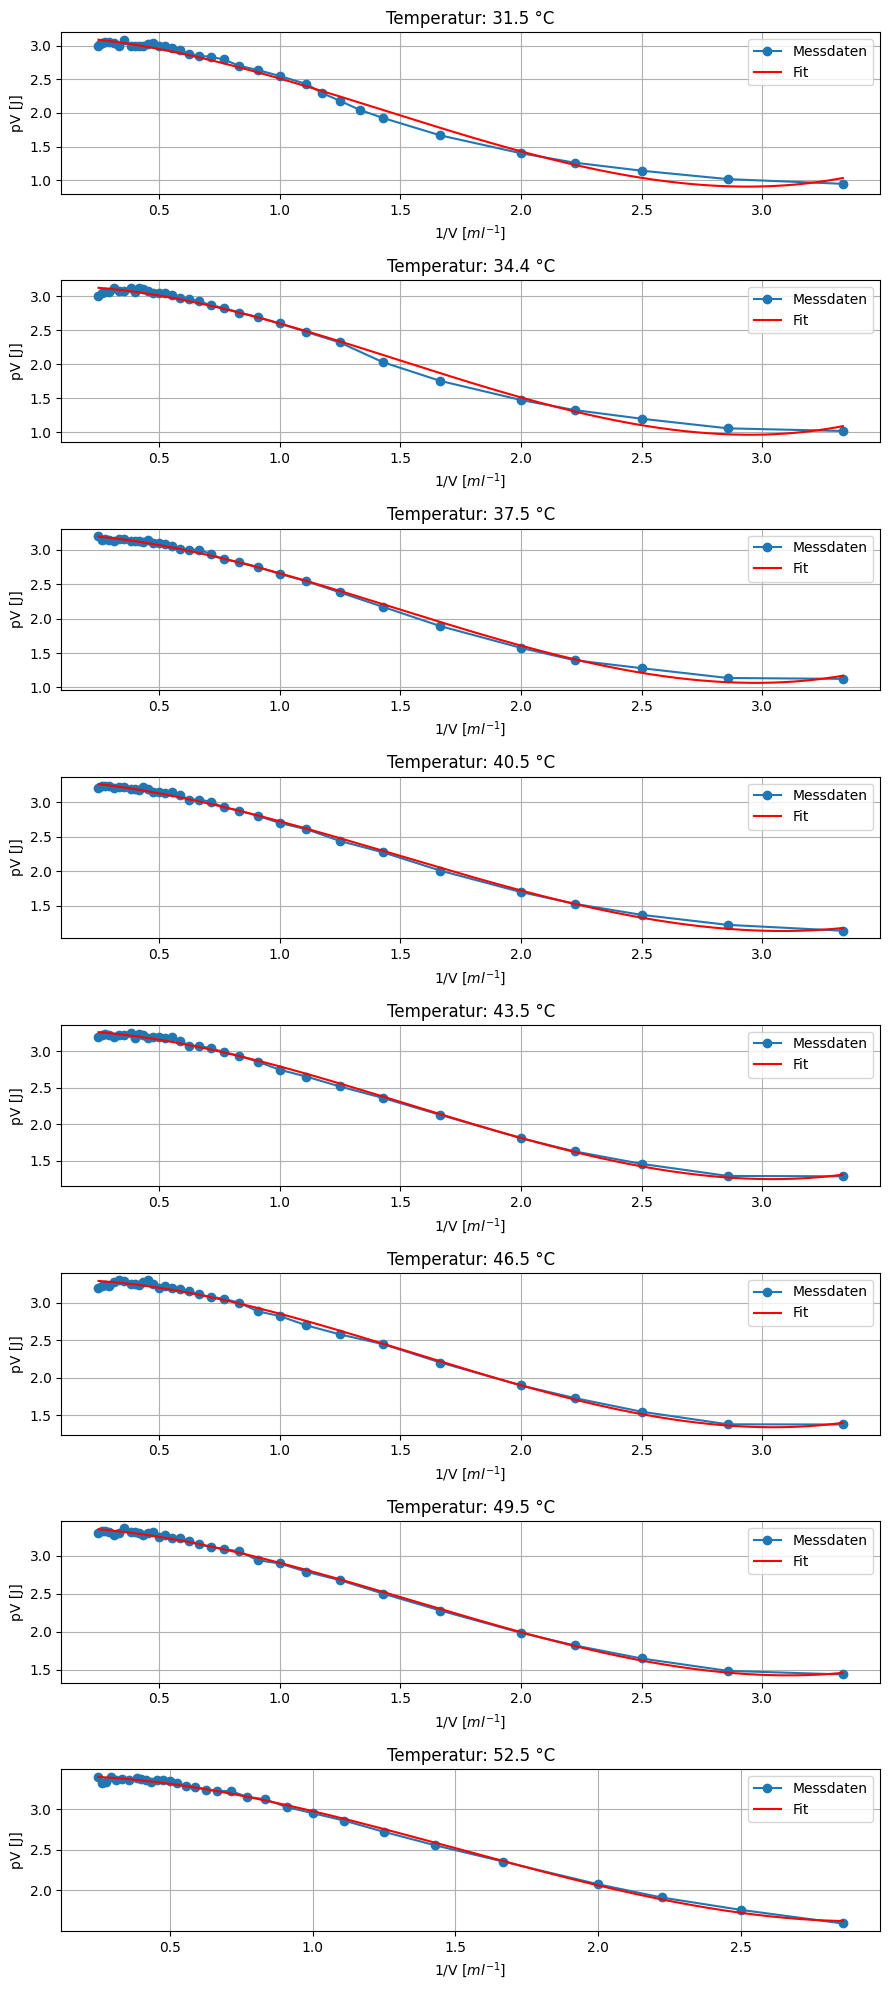

Durchschnittliche Stoffmenge: 0.001253085505489131 mol
Abweichung: 1.28e-05 mol


In [15]:
# | fig-cap: Mehrer Plots zu verschiedene Temperaturen, welche $pV$ in Abhängigkeit von $1/V$ plotten
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from natsort import natsorted
import os
from scipy.optimize import curve_fit

# Konstanten
R = 8.314462  # J/(mol*K)

# Fit-Funktion: Polynom 3. Ordnung
def poly3(x, a, b, c, d):
    return a * x**3 + b * x**2 + c * x + d

# Initialisierung der Ergebnislisten
pV = []
v_1 = []
n = []
y_0 = []
temperatur = []
fitts = []
fit_errors = []

# Datenordner
filepath = "Daten"
csv_files = [f for f in os.listdir(filepath) if f.endswith('.csv')]
csv_files = natsorted(csv_files)

for filename in csv_files:
    # Daten einlesen
    df = pd.read_csv(os.path.join(filepath, filename))
    df.columns = ['V[ml]', 'p [10^5 Pa]']

    # Temperatur extrahieren
    temp = float(filename[9:13].replace('_', '.'))

    # Messgrößen berechnen
    df['pV'] = df['V[ml]'] * df['p [10^5 Pa]']/10  # pV in J
    df['1/V'] = 1 / df['V[ml]']

    # Fit mit Polynom 3. Ordnung
    popt, _ = curve_fit(poly3, df['1/V'], df['pV'])
    predicted = poly3(df['1/V'], *popt)
    rmse = np.sqrt(np.mean((df['pV'] - predicted)**2))

    # Parameter extrahieren
    a, b, c, d = popt
    stoffmenge = (d) / (R * (temp + 273.15))  # mol

    # Speicherung
    pV.append(df['pV'])
    v_1.append(df['1/V'])
    n.append(stoffmenge)
    y_0.append(d)
    temperatur.append(temp)
    fitts.append(popt)
    fit_errors.append(rmse)

# Plot
plt.figure(figsize=(9, 20))
fig, axs = plt.subplots(8, 1, figsize=(9, 20))
axs = axs.flatten()

for i in range(len(axs)):
    x_vals = np.linspace(min(v_1[i]), max(v_1[i]), 500)
    axs[i].plot(v_1[i], pV[i], label='Messdaten', marker='o')
    axs[i].plot(x_vals, poly3(x_vals, *fitts[i]), color="red", label='Fit')

    axs[i].set_title(f"Temperatur: {temperatur[i]} °C")
    axs[i].set_xlabel("1/V [$ml^{{-1}}$]")
    axs[i].set_ylabel("pV [J]")
    axs[i].tick_params(axis='both', which='major')
    axs[i].grid(True)
    axs[i].legend()

plt.tight_layout()
plt.show()

#Ergebnisse in DataFrame speichern
# results = pd.DataFrame({
#     'Temperatur (°C)': temperatur,
#     'Stoffmenge (mol)': n,
#     'Achsenabschnitt (10^5 Pa)': y_0,
#     'Fit-Abweichung RMSE (10^5 Pa·ml)': fit_errors
# })
# print(results)


# Auswertung der Stoffmenge
durchschnittliche_stoffmenge = np.mean(n)
abweichung_stoffmenge = np.std(n)

print(f"Durchschnittliche Stoffmenge: {durchschnittliche_stoffmenge} mol")
print(f"Abweichung: {abweichung_stoffmenge:.2e} mol")


Mithilfe dieser Methode haben wir die durchschnittliche Stoffmenge von $12,53 \cdot 10^{-4} mol$ bestimmt. Hier auch nochmal die Werte für jede einzelne Messung:

| Temperatur (°C) | Stoffmenge (mol) | $\textrm{lim}_{V\rightarrow \infty}(pV)$ (10⁵ Pa) | Mittlere Abweichung (pV) |
|-----------------|------------------|---------------------------|-------------------------|
| 31.5            | 0.001245        | 31.528477                  | 0.592074  |
| 34.4            | 0.001233         | 31.526272                 |0.538834   |
| 37.5            | 0.001253           | 32.363284               |0.313201  |
| 40.5            | 0.001279         | 33.349060                  |0.296100   |
| 43.5            | 0.001251         | 32.936257                |0.298518 |
| 46.5            | 0.001245        | 33.081453                 | 0.365293|
| 49.5            | 0.001262       | 33.850738                |0.251238 |
| 52.5            | 0.001258         | 34.054129                 |0.264685  |
: Tabelle mit den einzelnen Messwerten und der ermittelten Stoffmenge


## Fehlerbetrachtung
Bei dieser Aufgabe gibt es zwei große Quellen für Abweichungen. Da wir kein ideales Gas haben, nutzen wir eine Näherung. Der Achsenabschnitt wird mithilfe eines Plots bestimmt, welcher natürlich Abweichungen von den Messdaten hat. Diese Abweichungen sind in der Tabelle mit angegeben. Außerdem wird für den Wert am Ende noch der Mittelwert von allen 8 Messungen berechnet. Dort war die Abweichung $1.28 \cdot 10^{-5} mol$.


# Aufgabe 5
## Bestimmung der Werte für Verdampfungswärme mit Fit
Für Aufgabe 5 sollen für aus den Messwerten die Verdampfungswärme, mittels der Clausius-Clapeyron-Gleichung, ermitteln. DIese lautet wie folgt:
$$\frac{d p_s}{dT} = \frac{Q_{23}}{T \cdot \Delta V_m}$$
Dabei ist $V_m$ der Unterschied des Volumens an der Maxwell-Geraden. Als erstes müssen wir also $p_s$ und $T$ als plot darstellen um daraus $\frac{dp_s}{dT}$ zu bekommen. Mithile der Formel und der Umstellung von $V_m = \frac{1}{n}(V_G-V_F)$ können wir dann die Verdampfungswärme berechnen.
$$Q_{23}(T) = \frac{(V_G - V_F)}{n}T\frac{dp_s}{dT}$$
$V_G$ und $V_F$ wurden dabei händisch aus den Plots in Aufgabe 2 entnommen. $n$ ist die Stoffmenge, die in Aufgabe 3 bestimmt wurde.

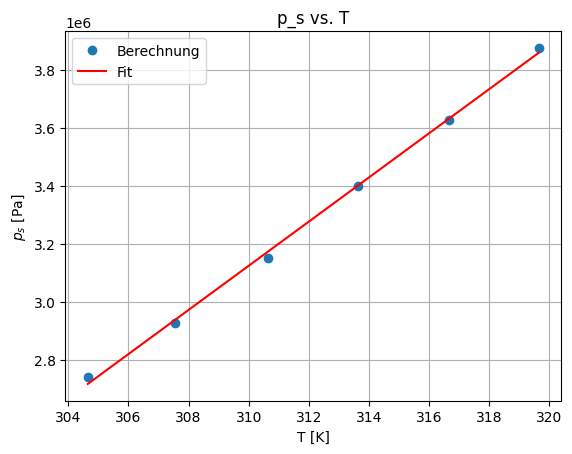

Q für T=304.65 K: 10179.64 J/mol
Q für T=307.55 K: 8408.08 J/mol
Q für T=310.65 K: 6605.53 J/mol
Q für T=313.65 K: 4763.80 J/mol
Q für T=316.65 K: 2885.62 J/mol
Q für T=319.65 K: 970.99 J/mol


In [ ]:
# | fig-cap: Sättigungsdruck gegen Temperatur
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.optimize import curve_fit

#Konstante
n = 0.001253 # in mol
a = 0.79 
b = 0.88*1e-4
R = 8.314 # J/(mol*K)
Q_23 = []
T_k = ((8 * a)/(27*R*b))

def Q_theo(Q_0, T):
    return Q_0 * (1 - T/T_k) ** (3/8)

# Gegebene Messwerte
T = np.array([304.65, 307.55, 310.65, 313.65, 316.65, 319.65])  # in K
p_s = np.array([2742000, 2925000, 3150000, 3400000, 3625000, 3875000])  # in Pa
v_g = np.array([0.9, 0.8, 0.7, 0.6, 0.5, 0.4])  # in m^3/mol
v_f = np.array([0.35, 0.35, 0.35, 0.35, 0.35, 0.35])  # in m^3/mol
v_g = v_g * 1e-6
v_f = v_f * 1e-6
fit_p_s = np.polyfit(T, p_s, 1)
T_T_k = T / T_k

#  Steigung der Geraden
slope = fit_p_s[0]
# y-Achsenabschnitt der Geraden
intercept = fit_p_s[1]

# Plot
plt.plot(T, p_s, 'o', label='Berechnung')
plt.plot(T, np.polyval(fit_p_s, T), 'r-', label='Fit')
plt.xlabel('T [K]')
plt.ylabel(r'$p_s$ [Pa]')
plt.legend()
plt.title('$p_s$ gegen $T$')
plt.grid(True)
plt.show()

# Verdampufngswärme berechnen
for i in range(len(T)):
    Q = ((v_g[i] - v_f[i]) * T[i] * slope)/n
    Q_23.append(Q)
    print(f"Q für T={T[i]} K: {Q:.2f} J/mol")

fit_q_23 = np.polyfit(T_T_k, Q_23, 1)
# Curve Fit für Q_theo
def Q_theo_func(T_T_k, Q_0):
    return Q_0 * (1 - T_T_k) ** (3/8)

popt, pcov = curve_fit(Q_theo_func, T_T_k, Q_23, p0=[10000])
Q_0_fit = popt[0]
Q_theo_fit = Q_theo_func(T_T_k, Q_0_fit)

# Plot der theoretischen Kurve
#plt.plot(T/T_k, Q_theo_fit, 'g--', label='Q_theo Fit')





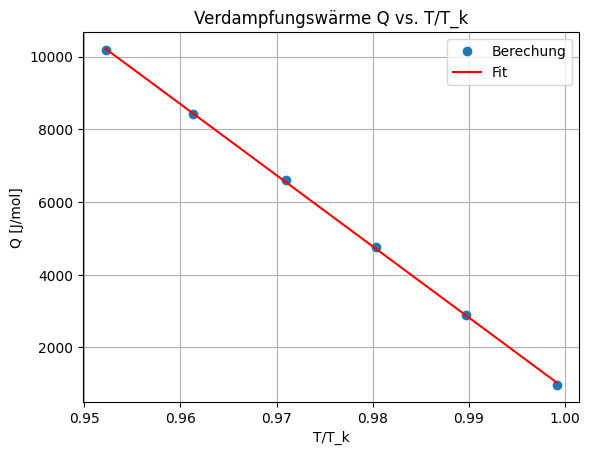

In [9]:
# | fig-cap: Verdampfungswärme Q vs. T/T_k mit Fit
# Plott der Verdampfungswärme zu T/Tk
plt.plot(T/T_k, Q_23, 'o', label='Berechung')
plt.plot(T/T_k, np.polyval(fit_q_23, T/T_k), 'r-', label='Fit')
plt.xlabel('T/T_k')
plt.ylabel('Q [J/mol]')
plt.legend()
plt.title('Verdampfungswärme Q vs. T/T_k')
plt.grid(True)
plt.show()

Für den zweiten Teil der Aufgabe haben wir die Verdampfungswärme Q im Vergleich zu $\frac{T}{T_k}$ angeschaut. $T_k$ ist die kritische Temperatur und wurde berechnet mithilfe der Formel:
$$T_k = \frac{8a}{27R b}$$
und für $SF_6$ sind die Konstanten: $a = a=0.79 N m^4 mol^{-2}$ und $b = 0.88\cdot 10^{-4} m^3 mol^{-1}$.

Je näher die Temperatur an der Kritischen ist, also je näher das Verhältnis an 1 ist, desto Temperaturabhängiger sollte die Verdampfungswärme sein. In unserem Fall war der Fit linear, wir glauben das liegt zum einen daran, dass wir sehr nahe an der kritischen Temperatur sind. Vor allem aber liegt es an den zu ungenauen Messmöglichkeiten. Die einzigen Variablen die die Formel hatte, waren die Volumina und die Temperatur. Die Temperatur haben wir immer in den gleichen Abständen gemessen und da das Volumen auch nur in 0,1 und 0,05ml Abständen gemessen wurde, kam dort bei unseren Messwerten ein lineares Verhältnis. Unsere Maxwell-Gerade ging immer bis 0,35ml und hat immer in 0,1 Abständen angefangen, für alle 3°C die wir geändert haben und daher kommt der lineare fit. Da der Fit jetzt überall linear ist, können wir nicht den korrekten y-Achsenabschnitt ablesen und somit nicht Q(0) bestimmen, mithilfe dessen wir näherungsweise an der kritischen Temperatur die Verdampfungswärme hätten berechnen können. Dafür müssen wir versuchen, einen möglichst ähnlichen anderen fit zu finden.

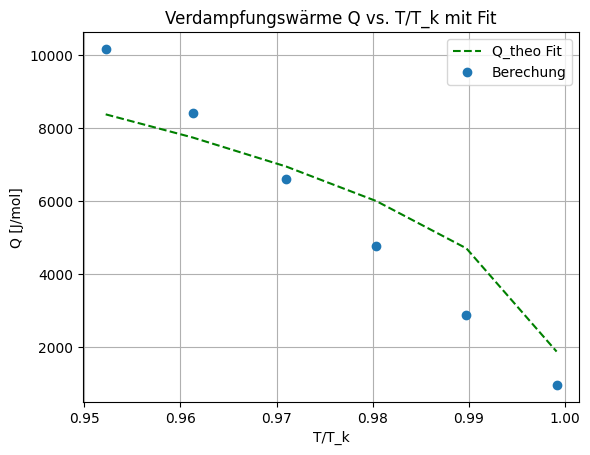

Q_0_fit = 26223.77 ± 2329.45 J/mol


In [6]:
# | fig-cap: Verdampfungswärme Q vs. T/T_k mit Fit zum ermitteln vom theoretischen Q_{23}(0)
plt.plot(T/T_k, Q_theo_fit, 'g--', label='Q_theo Fit')

# Plott der Verdampfungswärme zu T/Tk
plt.plot(T/T_k, Q_23, 'o', label='Berechung')
#plt.plot(T/T_k, np.polyval(fit_q_23, T/T_k), 'r-', label='Fit')
plt.xlabel('T/T_k')
plt.ylabel('Q [J/mol]')
plt.legend()
plt.title('Verdampfungswärme Q vs. T/T_k mit Fit')
plt.grid(True)
plt.show()
# Schreibe hier die Abweichung von Q_0_fit als Fehler (Standardabweichung aus pcov)
Q_0_err = np.sqrt(pcov[0, 0])
print(f"Q_0_fit = {Q_0_fit:.2f} ± {Q_0_err:.2f} J/mol")

Zum Schluss, wurde trotz der eher linearen Abhängig, nochmal ein Fit durchgeführt mit der näherungweise bestimmten Formel aus der Versuchsanleitung:
$$Q_{23}(T) = Q(0) \left(1 - \frac{T}{T_k}\right)^{(3/8)}$$
Dabei kamen wir für den Fit Parameter $Q_{23} = Q(0)$ auf $$26.22 \pm 23.29$ kJ/mol, wobei man eine sehr hohe Abweichung feststellt. Dies wird aber im folgenden sowie im vorherigen Abschnitt genauer diskutiert.

Wenn man die gemittelte molare Verdampfungswärme $Q_{23}$ mit der aus Aufgabe 3 vergleicht, fällt auf das diese sich ziemlich stark unterscheiden. Dieser entsteht durch die große Unsicherheiten was sich wohl auf die vielen Fehlereinflüsse und insbesondere auf das manuelle Ablesen der Volumina $V_F$ und $V_G$ aus den Plots in Aufgabe 2 zurückführen lässt, sowie das Ablösen der Messwerte an den Messgeräten beim Experiment, wobei auch immer eine Usicherheit von $\pm 0.25 \cdot 10^5 \, \mathrm{Pa}$ bzw. $\pm 0.025$ml besteht.
Ein anderer Messfehler könnte sein, Temperaturschwankungen die nicht berücksichtigt wurden, da es kein perfekt abgeschlossenens System und es somit auch keine perfekte isothermer Prozess ist. Wir reden hier zwar von, verhältnismäßig sehr kleinen Temperaturschwankungen, jedoch zeigt sich auch hier, dass die latente Wärme stark temperaturabhängig.

# Anhang
Hier sind nochmal alle einzelnen Plots zu den Isothermen, der Messungen.

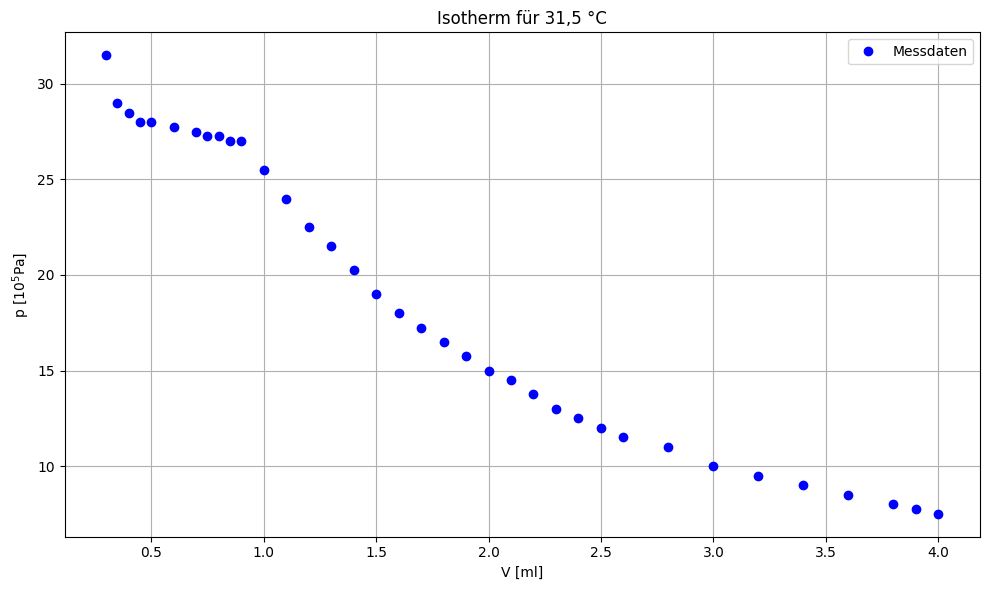

In [ ]:
# | fig-cap: Isotherme für 31,5 °C
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# CSV einlesen
df = pd.read_csv('Daten/Isotherm_31_5.csv')
df.columns = ['V[ml]', 'p [10^5 Pa]']


# Plot für die Messdaten
plt.figure(figsize=(10, 6))
plt.plot(df['V[ml]'], df['p [10^5 Pa]'],'o', label="Messdaten", color="blue",)
plt.xlabel("V [ml]")
plt.ylabel("p [$10^5$Pa]")
plt.title("Isotherme für 31,5 °C")
#plt.xscale('log')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


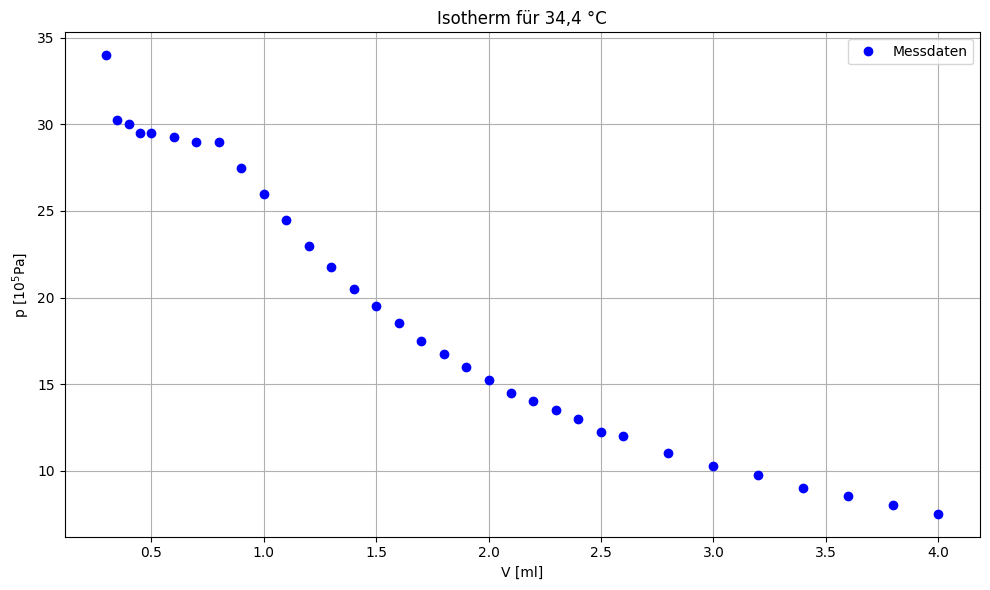

In [ ]:
# | fig-cap: Isotherme für 34,4 °C
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# CSV einlesen
df = pd.read_csv('Daten/Isotherm_34_4.csv')
df.columns = ['V[ml]', 'p [10^5 Pa]']


# Plot für die Messdaten
plt.figure(figsize=(10, 6))
plt.plot(df['V[ml]'], df['p [10^5 Pa]'],'o', label="Messdaten", color="blue",)
plt.xlabel("V [ml]")
plt.ylabel("p [$10^5$Pa]")
plt.title("Isotherme für 34,4 °C")
#plt.xscale('log')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


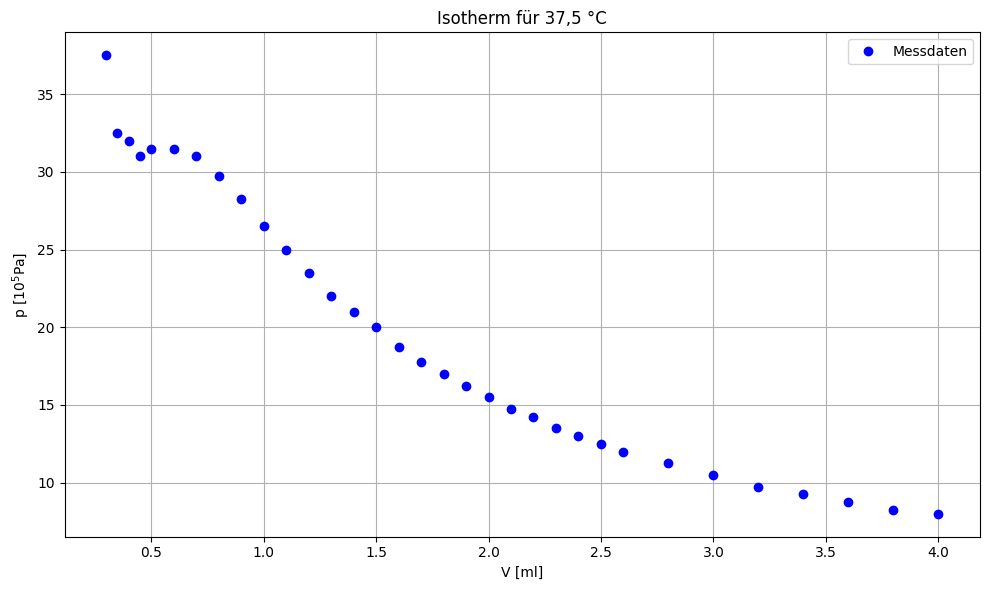

In [ ]:
# | fig-cap: Isotherme für 37,5 °C
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# CSV einlesen
df = pd.read_csv('Daten/Isotherm_37_5.csv')
df.columns = ['V[ml]', 'p [10^5 Pa]']


# Plot für die Messdaten
plt.figure(figsize=(10, 6))
plt.plot(df['V[ml]'], df['p [10^5 Pa]'],'o', label="Messdaten", color="blue",)
plt.xlabel("V [ml]")
plt.ylabel("p [$10^5$Pa]")
plt.title("Isotherme für 37,5 °C")
#plt.xscale('log')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


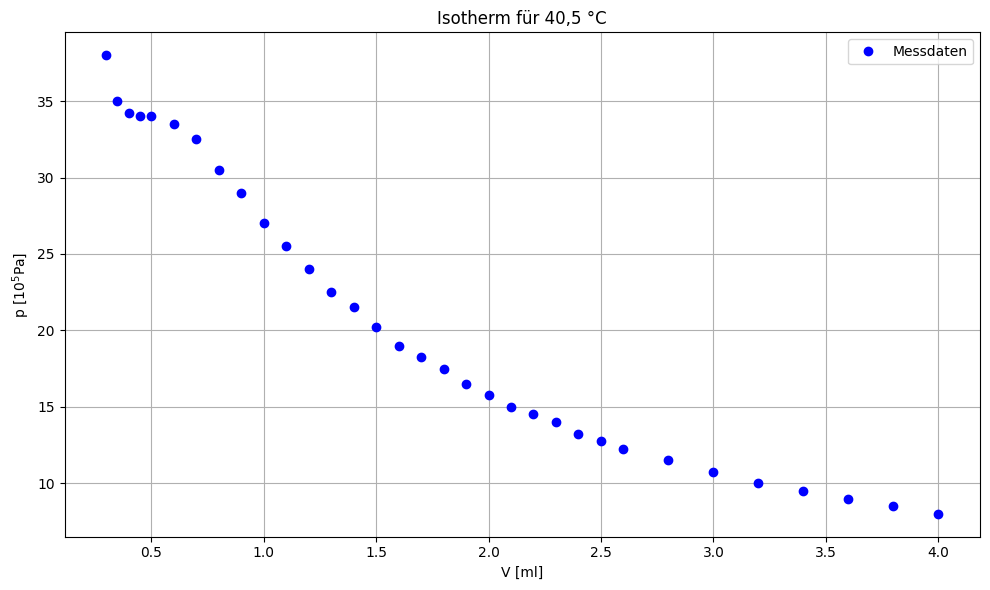

In [ ]:
# | fig-cap: Isotherme für 40,5 °C
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# CSV einlesen
df = pd.read_csv('Daten/Isotherm_40_5.csv')
df.columns = ['V[ml]', 'p [10^5 Pa]']


# Plot für die Messdaten
plt.figure(figsize=(10, 6))
plt.plot(df['V[ml]'], df['p [10^5 Pa]'],'o', label="Messdaten", color="blue",)
plt.xlabel("V [ml]")
plt.ylabel("p [$10^5$Pa]")
plt.title("Isotherme für 40,5 °C")
#plt.xscale('log')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


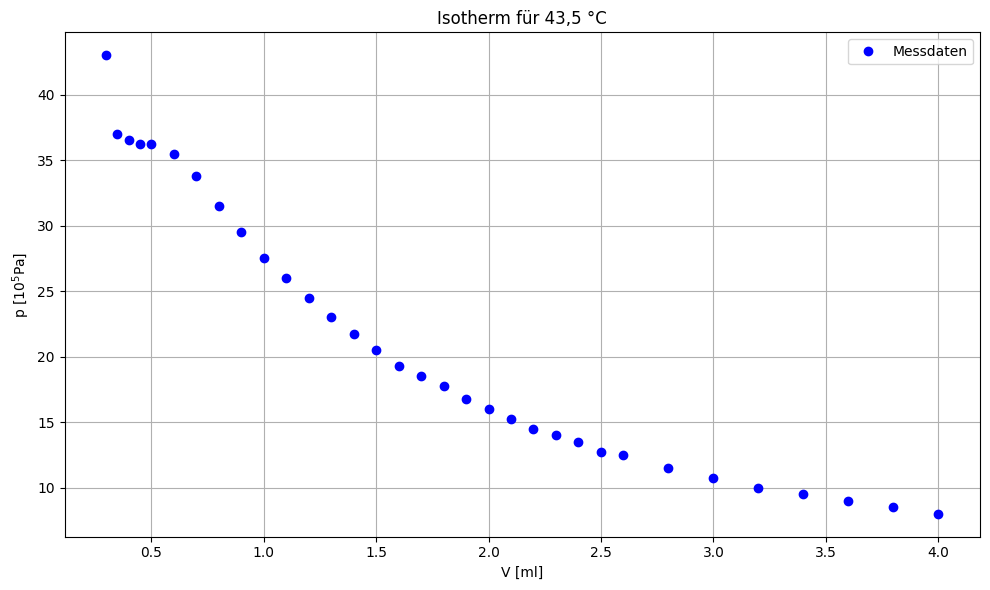

In [ ]:
# | fig-cap: Isotherme für 43,5 °C
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# CSV einlesen
df = pd.read_csv('Daten/Isotherm_43_5.csv')
df.columns = ['V[ml]', 'p [10^5 Pa]']


# Plot für die Messdaten
plt.figure(figsize=(10, 6))
plt.plot(df['V[ml]'], df['p [10^5 Pa]'],'o', label="Messdaten", color="blue",)
plt.xlabel("V [ml]")
plt.ylabel("p [$10^5$Pa]")
plt.title("Isotherme für 43,5 °C")
#plt.xscale('log')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


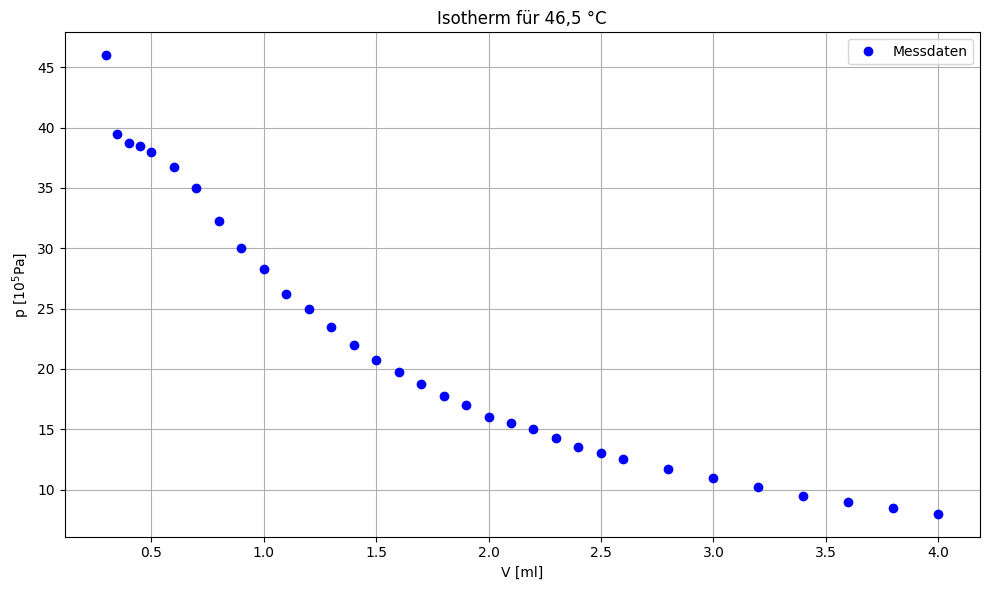

In [ ]:
# | fig-cap: Isotherme für 46,5 °C
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# CSV einlesen
df = pd.read_csv('Daten/Isotherm_46_5.csv')
df.columns = ['V[ml]', 'p [10^5 Pa]']


# Plot für die Messdaten
plt.figure(figsize=(10, 6))
plt.plot(df['V[ml]'], df['p [10^5 Pa]'],'o', label="Messdaten", color="blue",)
plt.xlabel("V [ml]")
plt.ylabel("p [$10^5$Pa]")
plt.title("Isotherme für 46,5 °C")
#plt.xscale('log')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


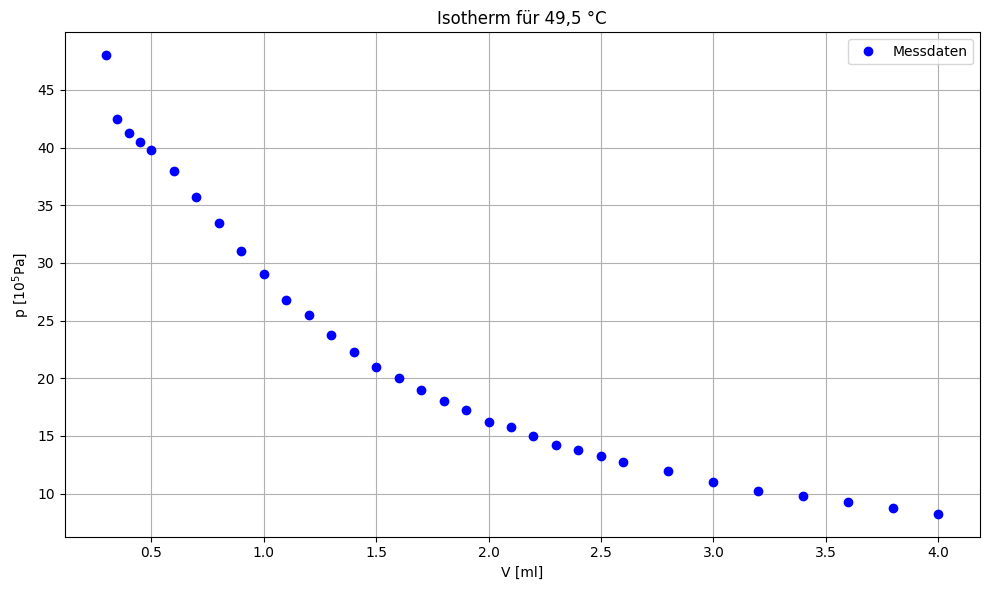

In [ ]:
# | fig-cap: Isotherme für 49,5 °C
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# CSV einlesen
df = pd.read_csv('Daten/Isotherm_49_5.csv')
df.columns = ['V[ml]', 'p [10^5 Pa]']


# Plot für die Messdaten
plt.figure(figsize=(10, 6))
plt.plot(df['V[ml]'], df['p [10^5 Pa]'],'o', label="Messdaten", color="blue",)
plt.xlabel("V [ml]")
plt.ylabel("p [$10^5$Pa]")
plt.title("Isotherm für 49,5 °C")
#plt.xscale('log')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


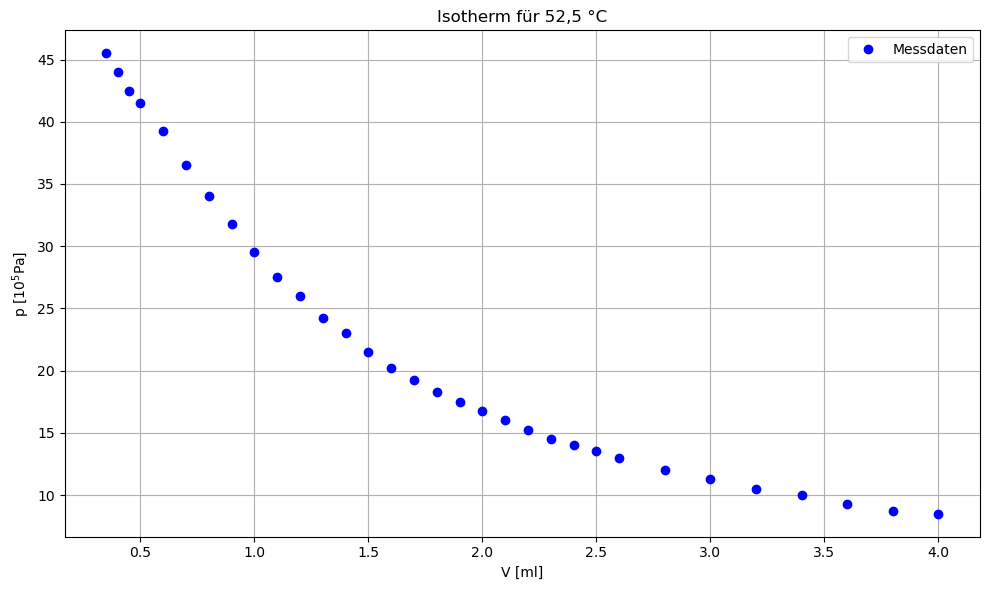

In [ ]:
# | fig-cap: Isotherme für 52,5 °C
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# CSV einlesen
df = pd.read_csv('Daten/Isotherm_52_5.csv')
df.columns = ['V[ml]', 'p [10^5 Pa]']


# Plot für die Messdaten
plt.figure(figsize=(10, 6))
plt.plot(df['V[ml]'], df['p [10^5 Pa]'],'o', label="Messdaten", color="blue",)
plt.xlabel("V [ml]")
plt.ylabel("p [$10^5$Pa]")
plt.title("Isotherme für 52,5 °C")
#plt.xscale('log')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
